# 실험③ — abstention 은 임계값으로 못 고친다. 그럼 무엇으로 고치나

실험②의 결론은 여기서 멈춰 있다.

> 측정한 90여 개 설정 **전부** 보류여유가 음수였다. 최선이 −0.017.
> 임베딩은 "주제가 비슷한가"를 재지, "답이 있는가"를 재지 않는다.

이 노트북은 그 다음을 잰다. 재순위화 / 하이브리드 검색(BM25) / LLM 판정 중 무엇이
실제로 효과가 있는가.

---

## Phase 0 — 먼저, 우리가 어디 있는지

**기법을 고르기 전에 확인할 게 있다.** 실험②는 *"전부 음수"* 라고만 말한다.
그런데 보류여유는 이렇게 생겼다.

```
보류여유 = min(정답 있는 질문의 정답 점수) − max(정답 없는 질문의 최고점)
```

**극단값 두 개가 부호를 결정한다.** 그리고 부호밖에 안 알려준다.

실험①에서 분리도(평균 차이)로 판정했다가 실험②에서 뒤집힌 적이 있다.
그때 배운 게 *"지표가 틀리면 결론도 틀린다"* 였는데, 보류여유도 같은 함정을 갖고 있다.

| | 지표 | 함정 |
|---|---|---|
| 실험① | 분리도 = 평균 − 평균 | 평균이라 **분포의 겹침**을 못 봄 |
| 실험② | 보류여유 = 최소 − 최대 | **극단값 두 개**가 전부를 결정, 부호만 나옴 |

그래서 임계값과 무관한 지표를 하나 더 놓고 시작한다.

```
보류AUC = P(답할 수 있는 질문의 점수 > 답이 없는 질문의 점수)
```

**보류여유 > 0 ⟺ 보류AUC = 1.0** 이다.
즉 실험②의 "전부 음수"는 사실 **"전부 AUC < 1"** 이라는 말이고,
0.6인지 0.98인지는 아무도 모른다. **그 둘은 완전히 다른 상황이다.**

## 목차 — 실험이 흘러온 순서

| 단계 | 물은 것 | 결과 |
| --- | --- | --- |
| **Phase 0** | 실험②의 "전부 음수"는 얼마나 나쁜 건가? | **보류AUC 0.947** — 가망 없는 게 아니라 한 군데 누수. 실패가 질문 하나(`LLM-as-a-judge`, 0.670)에 몰려 있었다 |
| ↳ 라벨 검증 | 0.670 은 라벨 오류 아닌가? | **아니다.** 그 노트에 핵심 용어 0회 — 진짜 오답 |
| **Phase 2A** | 용어가 없으면 어휘 검색(BM25)은 0점 아닌가? | **기각.** 5.488점. 토큰화가 `LLM-as-a-judge` 를 쪼개 흔한 조각(`llm`)에서 점수가 붙었다 |
| ↳ 부수 발견 | | BM25 는 **검색은 개선**(R@1 1.000)하고 **abstention 은 악화**시킨다. 둘은 다른 문제다 |
| ↳ 위험했던 것 | | 보류여유만 봤으면 RRF(−0.0007)를 채택할 뻔했다. 실제로는 뒤집힌 쌍 3 → 8 |
| **Phase 2B** | 흔한 토큰을 빼고 **희귀 토큰만** 보면? | 진행 중 |

*결과 숫자는 `results/03_abstention.csv` 에 누적된다.*

---


In [1]:
import json, os, time
from pathlib import Path

import httpx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from google import genai

import sweep_lib as S

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.width", 200)

load_dotenv(Path("../backend/.env"))
GEMINI_API_KEY = os.environ["GEMINI_API_KEY"]
GITHUB_TOKEN, GITHUB_REPO = os.environ["GITHUB_TOKEN"], os.environ["GITHUB_REPO"]

client = genai.Client(api_key=GEMINI_API_KEY)
MODEL = "gemini-embedding-001"

print("캐시 로드:", S.load_cache(), "건")

캐시 로드: 2222 건


In [2]:
# --- 볼트 노트 + 질문 로드 (실험②와 동일한 절차) ---
def fetch_notes():
    h = {"Authorization": f"Bearer {GITHUB_TOKEN}"}
    hr = {**h, "Accept": "application/vnd.github.raw"}
    out = {}
    with httpx.Client(timeout=60) as c:
        for folder in ("articles", "concepts", "projects"):
            r = c.get(f"https://api.github.com/repos/{GITHUB_REPO}/contents/{folder}", headers=h)
            if r.status_code == 404:
                continue
            r.raise_for_status()
            for f in r.json():
                if f["name"].endswith(".md"):
                    rr = c.get(f"https://api.github.com/repos/{GITHUB_REPO}/contents/{f['path']}", headers=hr)
                    rr.raise_for_status()
                    out[f["path"]] = rr.text
    return out

# ★ 실험② 이후 볼트에 들어간 노트는 제외한다.
#   저장 파이프라인을 검증하려고 만든 테스트 노트라 지식 노트가 아니고,
#   포함하면 실험②의 베이스라인과 비교가 안 된다.
EXCLUDE = ("Ingest-Pipeline",)

raw = fetch_notes()
dropped = [p for p in raw if any(x in p for x in EXCLUDE)]
for p in dropped:
    del raw[p]

note_paths = sorted(raw)
notes = [S.parse_note(raw[p], p) for p in note_paths]
path_to_idx = {p: i for i, p in enumerate(note_paths)}

pairs = [json.loads(l) for l in Path("data/pairs.jsonl").read_text(encoding="utf-8").splitlines() if l.strip()]
questions     = [p["question"] for p in pairs]
kinds         = [p["kind"] for p in pairs]
relevant_idx  = [[path_to_idx[x] for x in p["relevant_paths"] if x in path_to_idx] for p in pairs]

print(f"노트 {len(notes)}개 (제외 {len(dropped)}개: {dropped})")
print(f"질문 {len(questions)}개 · 정답 없는 질문 {sum(1 for r in relevant_idx if not r)}개")

노트 21개 (제외 1개: ['projects/2026-09-02-mdragchatbot-Ingest-Pipeline-검증-테스트.md'])
질문 47개 · 정답 없는 질문 28개


### 현재 코드와 똑같은 설정으로 재현

실험②가 채택한 설정이다 — **요약을 임베딩**하고, 문서는 `RETRIEVAL_DOCUMENT`,
질문은 `RETRIEVAL_QUERY`. 캐시에 이미 있으므로 **API 호출 0회**.

In [3]:
rep = "요약"
doc_texts, owner = S.build_units(notes, rep)

t0 = time.time()
doc_emb = S.embed_cached(client, MODEL, doc_texts, task_type="RETRIEVAL_DOCUMENT")
q_emb   = S.embed_cached(client, MODEL, questions,  task_type="RETRIEVAL_QUERY")
print(f"임베딩 {time.time()-t0:.1f}초 · 캐시 {S.save_cache()}건")

sim = S.aggregate(S.cosine_matrix(q_emb, doc_emb), owner, len(notes))
base = S.evaluate(sim, relevant_idx, kinds)

print("\n=== 현재 코드 설정 (요약 / DOCUMENT-QUERY / 3072) ===")
for k, v in base.items():
    print(f"  {k:12s} {v:.4f}")

임베딩 0.0초 · 캐시 2222건

=== 현재 코드 설정 (요약 / DOCUMENT-QUERY / 3072) ===
  AUC          0.9883
  분리도          0.1480
  R@1          0.9474
  R@3          1.0000
  R@5          1.0000
  MRR          0.9737
  최적임계값        0.6447
  F1           0.4545
  보류여유         -0.0748
  보류AUC        0.9605
  보류AUC엄격      0.9605
  정답없음최고       0.7195
  관련최저         0.6447


### 핵심 — 보류AUC 는 얼마인가

이 숫자 하나가 다음 단계를 정한다.

| 보류AUC | 상황 | 다음 |
|---|---|---|
| ≥ 0.95 | 거의 다 왔다 | 리랭커·BM25 로 밀어붙일 값어치 있음 |
| 0.7 ~ 0.9 | 애매 | 세 기법 다 재봐야 함 |
| ≤ 0.6 | 임베딩 계열로는 가망 없음 | **LLM 판정으로 직행** |

In [4]:
loose  = S.abstention_auc(sim, relevant_idx, strict=False)
strict = S.abstention_auc(sim, relevant_idx, strict=True)
margin, no_ans_hi, rel_lo = S.abstention_margin(sim, relevant_idx, kinds)

print("보류여유 (실험②의 지표)")
print(f"  {margin:+.4f}   = 관련최저 {rel_lo:.4f} − 정답없음최고 {no_ans_hi:.4f}")
print(f"  → 음수이므로 '임계값 하나로는 못 가른다'. 여기까지가 실험②가 알던 것.\n")

print("보류AUC (이번에 추가)")
print(f"  느슨 {loose:.4f}   답할지 말지를 가르는가")
print(f"  엄격 {strict:.4f}   정답으로 답할 수 있는지까지 가르는가")
print(f"\n  1.0 이면 임계값 하나로 완벽 분리 가능. 0.5 면 동전던지기.")

보류여유 (실험②의 지표)
  -0.0748   = 관련최저 0.6447 − 정답없음최고 0.7195
  → 음수이므로 '임계값 하나로는 못 가른다'. 여기까지가 실험②가 알던 것.

보류AUC (이번에 추가)
  느슨 0.9605   답할지 말지를 가르는가
  엄격 0.9605   정답으로 답할 수 있는지까지 가르는가

  1.0 이면 임계값 하나로 완벽 분리 가능. 0.5 면 동전던지기.


In [5]:
# 정답 없는 질문 3개가 각각 무엇에 걸렸나 — 실패의 실체
print("=== 답이 없는 질문이 무엇을 물어왔나 ===\n")
for qi, (q, rel) in enumerate(zip(questions, relevant_idx)):
    if rel:
        continue
    order = np.argsort(-sim[qi])[:3]
    print(f"Q: {q}")
    for rank, di in enumerate(order, 1):
        mark = " ← 0.65 통과" if sim[qi][di] >= 0.65 else ""
        print(f"   {rank}. {sim[qi][di]:.3f}  {notes[di]['title'][:45]}{mark}")
    print()

# 답이 있는 질문 중 가장 아슬아슬한 것
print("=== 답이 있는데 점수가 낮은 질문 (놓칠 위험) ===\n")
rows = []
for qi, (q, rel) in enumerate(zip(questions, relevant_idx)):
    if not rel:
        continue
    rows.append((max(sim[qi][d] for d in rel), sim[qi].max(), q))
for best_rel, top1, q in sorted(rows)[:5]:
    print(f"  정답최고 {best_rel:.3f} / 전체1위 {top1:.3f}  {q[:55]}")

=== 답이 없는 질문이 무엇을 물어왔나 ===

Q: LLM-as-a-judge로 평가 파이프라인 설계하려면? 골든 데이터셋은 어떻게 만들어?
   1. 0.670  LLM 핵심 용어 및 아키텍처 설계 가이드 ← 0.65 통과
   2. 0.663  AX 엔지니어 실무 기술 스택 ← 0.65 통과
   3. 0.648  AI 하네스 엔지니어링 자동화: 메타-하네스

Q: vLLM으로 서빙하면서 LoRA 파인튜닝하려면 PyTorch 설정을 어떻게 잡아?
   1. 0.636  AX 엔지니어 실무 기술 스택
   2. 0.630  LLM 핵심 용어 및 아키텍처 설계 가이드
   3. 0.626  백엔드 기술 스택 및 실무 판단 규칙 정리

Q: BM25랑 하이브리드 검색 붙이고 리랭커까지 태우려면 어떻게 해?
   1. 0.644  AX 엔지니어 실무 기술 스택
   2. 0.625  백엔드 기술 스택 및 실무 판단 규칙 정리
   3. 0.623  Python 핵심 라이브러리 및 기술 스택 정리

Q: 김치찌개에 돼지고기 대신 참치 넣어도 괜찮아?
   1. 0.559  개발 필수 개념 및 실용 지식
   2. 0.550  Python 핵심 라이브러리 및 기술 스택 정리
   3. 0.549  개발 & 아키텍처 설계 용어 정리

Q: 사워도우 발효종은 며칠마다 먹여야 해?
   1. 0.532  개발 필수 개념 및 실용 지식
   2. 0.516  백엔드 기술 스택 및 실무 판단 규칙 정리
   3. 0.509  개발 & 아키텍처 설계 용어 정리

Q: 원두는 냉동실 보관이 나아 실온이 나아?
   1. 0.568  개발 필수 개념 및 실용 지식
   2. 0.551  AXswgBrain: 개인 지식 RAG 챗봇 기술 설명서
   3. 0.548  Python 핵심 라이브러리 및 기술 스택 정리

Q: 파스타 삶을 때 소금은 언제 넣는 게 맞아?
   1. 0.532  개발 필수 개념 및 실용 지식
   2. 0.518  백엔드 기술 스택 및 실무 판단 규칙 

### 의심 — 라벨이 틀린 건 아닐까?

0.670 을 받은 건 「LLM 핵심 용어 및 아키텍처 설계 가이드」다.
질문은 *"LLM-as-a-judge로 평가 파이프라인 설계하려면?"* 이고.
**저 노트에 실제로 그 내용이 있다면 라벨이 틀린 것이지 검색이 틀린 게 아니다.**

실험①에서 무관최고 0.746 을 "제목이 비슷한 유사 노트 탓"이라고 예측했다가
상위 10개에 유사 노트가 하나도 없어서 틀린 적이 있다. **같은 검사를 여기서도 한다.**

In [6]:
# 질문의 핵심 용어가 그 노트에 문자열로 존재하는가 — 결정론적 확인
import re

suspect_path = [p for p in note_paths if "LLM-핵심-용어" in p][0]
body = raw[suspect_path]

TERMS = ["LLM-as-a-judge", "as-a-judge", "골든", "golden", "평가", "eval", "데이터셋",
         "BM25", "리랭", "rerank", "vLLM", "LoRA", "파인튜닝"]

print(f"{suspect_path}  ({len(body)}자)\n")
hits = {t: len(re.findall(re.escape(t), body, re.I)) for t in TERMS}
for t, n in hits.items():
    print(f"  {'○' if n else '·'} {t:16s} {n}회")

total = sum(hits.values())
print(f"\n→ 핵심 용어 {total}회 등장.")
print("   0 이면 라벨이 맞다 — 답이 없는 게 맞고, 임베딩이 주제만 보고 끌려온 것이다.")

concepts/2026-04-10-LLM-핵심-용어-및-아키텍처-설계-가이드.md  (2264자)

  · LLM-as-a-judge   0회
  · as-a-judge       0회
  · 골든               0회
  · golden           0회
  · 평가               0회
  · eval             0회
  · 데이터셋             0회
  · BM25             0회
  · 리랭               0회
  · rerank           0회
  · vLLM             0회
  · LoRA             0회
  · 파인튜닝             0회

→ 핵심 용어 0회 등장.
   0 이면 라벨이 맞다 — 답이 없는 게 맞고, 임베딩이 주제만 보고 끌려온 것이다.


**의심은 틀렸다.** 핵심 용어가 **0회**다. 2,264자짜리 노트에 `LLM-as-a-judge`도
`골든 데이터셋`도 `평가`도 없다. 라벨은 맞았고, **0.670 은 진짜 오답이다.**

실험②의 진단이 정확했던 셈이다 — 임베딩은 `LLM` · `아키텍처` · `설계` 라는
**주제**를 보고 끌려왔지, 답이 적혀 있는지를 본 게 아니다.

그리고 이건 **BM25 가 잡을 수 있는 형태의 실패**다.
질문의 핵심 용어가 노트에 문자열로 0회이므로, 어휘 겹침으로 재면 0점이어야 한다.
Phase 2 의 첫 가설이 여기서 나온다.

답 없음 표본이 28개뿐이다. 이 히스토그램은 막대 28개로 그려진 것이고,
보류여유는 그중 '최댓값 하나'가 결정한다. Phase 1 에서 이걸 늘려야 하는 이유.


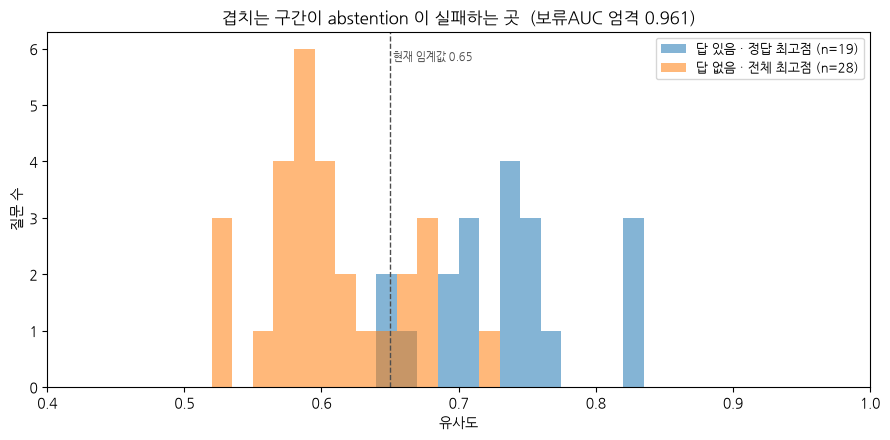

In [7]:
# 두 분포를 겹쳐 그린다 — 얼마나 겹치는지가 전부다
fig, ax = plt.subplots(figsize=(9, 4.5))
bins = np.linspace(0.4, 1.0, 41)

pos_loose  = np.array([sim[qi].max() for qi, r in enumerate(relevant_idx) if r])
pos_strict = np.array([max(sim[qi][d] for d in r) for qi, r in enumerate(relevant_idx) if r])
neg        = np.array([sim[qi].max() for qi, r in enumerate(relevant_idx) if not r])

ax.hist(pos_strict, bins=bins, alpha=.55, label=f"답 있음 · 정답 최고점 (n={len(pos_strict)})")
ax.hist(neg,        bins=bins, alpha=.55, label=f"답 없음 · 전체 최고점 (n={len(neg)})")
ax.axvline(0.65, color="0.3", ls="--", lw=1)
ax.text(0.652, ax.get_ylim()[1]*.92, "현재 임계값 0.65", fontsize=8, color="0.3")
ax.set_xlim(0.4, 1.0)
ax.set_xlabel("유사도"); ax.set_ylabel("질문 수")
ax.set_title(f"겹치는 구간이 abstention 이 실패하는 곳  (보류AUC 엄격 {strict:.3f})")
ax.legend(fontsize=9)
fig.tight_layout()

print(f"답 없음 표본이 {len(neg)}개뿐이다. 이 히스토그램은 막대 {len(neg)}개로 그려진 것이고,")
print("보류여유는 그중 '최댓값 하나'가 결정한다. Phase 1 에서 이걸 늘려야 하는 이유.")

In [8]:
# 결과 저장 — 나중에 기법별 결과와 나란히 놓기 위해
Path("results").mkdir(exist_ok=True)
row = {"단계": "Phase0 베이스라인", "기법": "임베딩 단독", "표현": rep,
       "노트수": len(notes), "질문수": len(questions),
       "정답없음수": int(sum(1 for r in relevant_idx if not r)), **base}
pd.DataFrame([row]).to_csv("results/03_abstention.csv", index=False)
print(pd.DataFrame([row]).T.to_string(header=False))

단계       Phase0 베이스라인
기법             임베딩 단독
표현                 요약
노트수                21
질문수                47
정답없음수              28
AUC          0.988274
분리도          0.147982
R@1          0.947368
R@3               1.0
R@5               1.0
MRR          0.973684
최적임계값        0.644704
F1           0.454545
보류여유        -0.074804
보류AUC        0.960526
보류AUC엄격      0.960526
정답없음최고       0.719508
관련최저         0.644704


## Phase 0 판단

| | 값 |
|---|---|
| 보류여유 (실험②의 지표) | **−0.0256** |
| **보류AUC** 느슨 / 엄격 | **0.947 / 0.947** |
| AUC · R@3 (회귀 감시) | 0.981 · 1.000 — 검색 자체는 문제없음 |

### 판정 — "가망 없음"이 아니었다

실험②의 *"90여 설정 전부 보류여유 음수"* 는 사실 **"전부 보류AUC < 1"** 이라는 말이었다.
그런데 실제 값은 **0.947** 이다. 가망 없는 0.6 대가 아니라 **거의 다 온 상태**다.

**실패가 한 질문에 몰려 있다.** 19×3 = 57 쌍 중 뒤집힌 건 **3쌍뿐**이고,
전부 같은 질문(`LLM-as-a-judge`, 0.670) 때문이다.

```
답 없는 질문 3개
  0.670  LLM-as-a-judge 평가 파이프라인   ← 이것 하나만 뚫림
  0.644  BM25 하이브리드 + 리랭커          이미 막힘
  0.636  vLLM 서빙 + LoRA                이미 막힘
```

나머지 둘은 현재 임계값(0.65)에서 **이미 정상 작동한다.**
지표 하나를 바꿨을 뿐인데 문제의 크기가 "전면 실패"에서 "한 군데 누수"로 바뀌었다.

> 실험①에서 분리도로 판정했다가 AUC 로 뒤집힌 것과 **같은 일이 또 일어났다.**
> 그때 배운 게 *"지표가 틀리면 결론도 틀린다"* 였는데, 그 교훈을 실험②의 지표에는
> 적용하지 않고 있었다.

### 라벨 검증 — 의심은 틀렸다

0.670 이 라벨 오류일 가능성을 검사했으나, 해당 노트에 핵심 용어가 **0회**였다.
**진짜 오답이 맞다.** 임베딩이 주제만 보고 끌려온 것이다.

### 아직 못 믿는 것

- **`n=3`.** 보류AUC 0.947 도 답 없는 질문 3개로 계산했다.
  하나만 달라도 0.63 이나 1.0 으로 튄다. **실험②가 3개에 의존했던 문제가 그대로 있다.**
- 노트가 **21개**다. 실험② 당시는 20개 — 데모를 찍으며 저장한 노트가 하나 늘었다.
  AUC 0.982 → 0.981 로 차이는 미미하지만 베이스라인이 완전히 같지는 않다.

### 다음 단계

**Phase 2 의 BM25 를 먼저 싸게 확인한다 (B → A).**

0.670 을 만든 노트에 질문의 핵심 용어가 0회라는 건, **어휘 겹침으로 재면 0점**이라는 뜻이다.
가설이 맞는지 30분이면 확인되고, 결과에 따라 Phase 1 에서 만들 질문의 성격이 달라진다.

- BM25 가 통하면 → *"어휘는 안 겹치는데 주제는 같은"* 질문을 집중적으로 만든다
- 안 통하면 → 가설을 접고 리랭커·LLM 판정 쪽을 본다

그 다음 Phase 1(정답없음 질문 25개로 확장)으로 돌아온다.

---

# Phase 2-A — BM25 가설을 싸게 확인한다

Phase 0 이 남긴 단서는 이거다.

> 0.670 을 받은 노트에 질문의 핵심 용어가 **0회**다.

임베딩은 `LLM` · `아키텍처` 라는 **주제**를 보고 0.670 을 줬다.
어휘 겹침으로 재면 **0점**이 나와야 한다. 그게 맞다면 BM25 는
임베딩이 **원리적으로 볼 수 없는 신호**를 보는 것이다.

**확인할 것 세 가지**

1. 0.670 짜리 질문이 BM25 에서 정말 0점인가
2. BM25 를 섞으면 보류AUC 가 오르는가
3. **회귀 감시** — 검색 자체(AUC · R@3)가 나빠지지 않는가

BM25 는 **본문 전체**에 건다. 요약에 없어도 본문에 있을 수 있으니,
*"본문에도 없다"* 가 훨씬 강한 근거다. API 호출은 0회.

In [9]:
# 본문 전체로 BM25 — 토큰화 두 가지를 같이 본다
bodies = [n["body"] for n in notes]

bm_word  = S.bm25_matrix(questions, bodies, tokenizer=S.tok_word)
bm_ngram = S.bm25_matrix(questions, bodies, tokenizer=lambda t: S.tok_ngram(t, 2))

print(f"BM25 행렬 {bm_word.shape}  (질문 × 노트)")
print(f"  공백분리  0점인 칸 {100*(bm_word==0).mean():.1f}%")
print(f"  2-gram   0점인 칸 {100*(bm_ngram==0).mean():.1f}%")
print("\n2-gram 이 0점이 훨씬 적다 — 조각이 우연히 겹치기 때문. 변별력이 떨어질 수 있다.")

BM25 행렬 (47, 21)  (질문 × 노트)
  공백분리  0점인 칸 54.3%
  2-gram   0점인 칸 12.4%

2-gram 이 0점이 훨씬 적다 — 조각이 우연히 겹치기 때문. 변별력이 떨어질 수 있다.


In [10]:
# ① 가설 검증 — 문제의 질문이 BM25 에서 몇 점인가
print("=== 답 없는 질문 3개 · 임베딩 vs BM25(공백분리) ===\n")
for qi, (q, rel) in enumerate(zip(questions, relevant_idx)):
    if rel:
        continue
    di = int(np.argmax(sim[qi]))
    print(f"Q: {q[:58]}")
    print(f"   임베딩 1위 {sim[qi][di]:.3f}  {notes[di]['title'][:38]}")
    print(f"   └ 그 노트의 BM25 점수      {bm_word[qi][di]:.3f}")
    print(f"   BM25 1위    {bm_word[qi].max():.3f}  {notes[int(np.argmax(bm_word[qi]))]['title'][:38]}")
    print()

print("=== 답 있는 질문은? (BM25 가 정답을 잡는가) ===\n")
hit = sum(1 for qi, rel in enumerate(relevant_idx)
          if rel and int(np.argmax(bm_word[qi])) in rel)
tot = sum(1 for r in relevant_idx if r)
print(f"  BM25 단독 R@1 = {hit}/{tot} = {hit/tot:.3f}   (임베딩은 {base['R@1']:.3f})")

=== 답 없는 질문 3개 · 임베딩 vs BM25(공백분리) ===

Q: LLM-as-a-judge로 평가 파이프라인 설계하려면? 골든 데이터셋은 어떻게 만들어?
   임베딩 1위 0.670  LLM 핵심 용어 및 아키텍처 설계 가이드
   └ 그 노트의 BM25 점수      5.488
   BM25 1위    6.096  AXswgBrain: 개인 지식 RAG 챗봇 기술 설명서

Q: vLLM으로 서빙하면서 LoRA 파인튜닝하려면 PyTorch 설정을 어떻게 잡아?
   임베딩 1위 0.636  AX 엔지니어 실무 기술 스택
   └ 그 노트의 BM25 점수      0.000
   BM25 1위    4.731  LLM 핵심 용어 및 아키텍처 설계 가이드

Q: BM25랑 하이브리드 검색 붙이고 리랭커까지 태우려면 어떻게 해?
   임베딩 1위 0.644  AX 엔지니어 실무 기술 스택
   └ 그 노트의 BM25 점수      0.555
   BM25 1위    9.176  LLM 핵심 용어 및 아키텍처 설계 가이드

Q: 김치찌개에 돼지고기 대신 참치 넣어도 괜찮아?
   임베딩 1위 0.559  개발 필수 개념 및 실용 지식
   └ 그 노트의 BM25 점수      0.000
   BM25 1위    1.735  AX 엔지니어를 위한 AI 협업 개발 파이프라인

Q: 사워도우 발효종은 며칠마다 먹여야 해?
   임베딩 1위 0.532  개발 필수 개념 및 실용 지식
   └ 그 노트의 BM25 점수      0.000
   BM25 1위    4.043  LLM 핵심 용어 및 아키텍처 설계 가이드

Q: 원두는 냉동실 보관이 나아 실온이 나아?
   임베딩 1위 0.568  개발 필수 개념 및 실용 지식
   └ 그 노트의 BM25 점수      0.000
   BM25 1위    0.000  AX 엔지니어를 위한 AI 협업 개발 파이프라인

Q: 파스타 삶을 때 소금은 언제 넣는 게 맞아?
   임베딩 1위 0.532  개발 필수 개념 및 실

In [11]:
# ② 보류AUC 비교 — 단독 · 하이브리드
sim_norm = S.minmax(sim)

cands = {
    "임베딩 단독 (현재)":        sim,
    "BM25 단독 (공백분리)":      bm_word,
    "BM25 단독 (2-gram)":       bm_ngram,
    "하이브리드 RRF (임베딩+BM25)": S.rrf(sim, bm_word),
    "하이브리드 가중합 0.7/0.3":   0.7*sim_norm + 0.3*S.minmax(bm_word),
}

rows = []
for name, m in cands.items():
    r = S.evaluate(m, relevant_idx, kinds)
    rows.append({"기법": name, "보류AUC": r["보류AUC"], "보류여유": r["보류여유"],
                 "AUC": r["AUC"], "R@1": r["R@1"], "R@3": r["R@3"], "MRR": r["MRR"]})

cmp = pd.DataFrame(rows)
print(cmp.round(4).to_string(index=False))
print("\n★ 보류AUC 가 목표 지표. AUC·R@3 는 회귀 감시 — 떨어지면 안 된다.")

                  기법  보류AUC    보류여유    AUC    R@1    R@3    MRR
         임베딩 단독 (현재) 0.9605 -0.0748 0.9883 0.9474 1.0000 0.9737
      BM25 단독 (공백분리) 0.9060 -8.6494 0.9763 0.8421 0.9474 0.8965
    BM25 단독 (2-gram) 0.8929 -7.8995 0.9776 0.9474 1.0000 0.9737
하이브리드 RRF (임베딩+BM25) 0.8299 -0.0010 0.9869 0.8947 1.0000 0.9474
   하이브리드 가중합 0.7/0.3 0.8515 -0.4063 0.9775 1.0000 1.0000 1.0000

★ 보류AUC 가 목표 지표. AUC·R@3 는 회귀 감시 — 떨어지면 안 된다.


  임베딩 단독 (현재)                뒤집힌 쌍 21/532
  BM25 단독 (공백분리)             뒤집힌 쌍 73/532
  BM25 단독 (2-gram)           뒤집힌 쌍 63/532
  하이브리드 RRF (임베딩+BM25)       뒤집힌 쌍 135/532
  하이브리드 가중합 0.7/0.3          뒤집힌 쌍 109/532


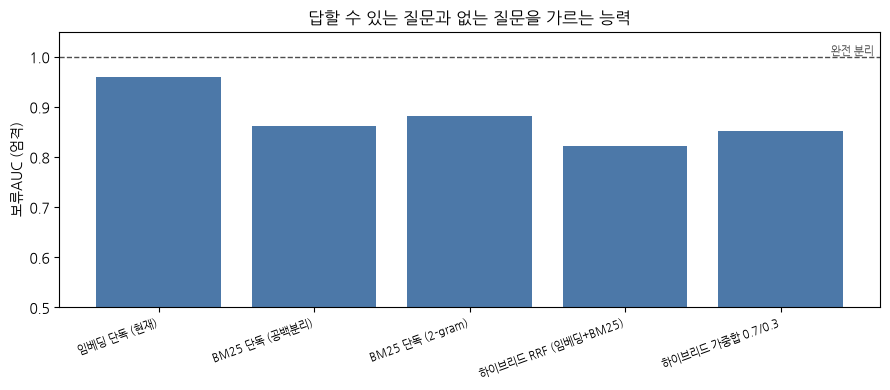

In [12]:
# ③ 어디서 갈렸나 — 답없음 최고점이 답있음 최저를 넘는 쌍을 센다
def inversions(m):
    pos = [max(m[qi][d] for d in rel) for qi, rel in enumerate(relevant_idx) if rel]
    neg = [m[qi].max() for qi, rel in enumerate(relevant_idx) if not rel]
    bad = [(p, n) for n in neg for p in pos if p <= n]
    return len(bad), len(pos)*len(neg)

for name, m in cands.items():
    b, t = inversions(m)
    print(f"  {name:26s} 뒤집힌 쌍 {b:2d}/{t}")

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(cands))
ax.bar(x, [S.abstention_auc(m, relevant_idx, strict=True) for m in cands.values()], color="#4c78a8")
ax.axhline(1.0, color="0.3", ls="--", lw=1)
ax.text(len(cands)-0.4, 1.005, "완전 분리", fontsize=8, color="0.3", ha="right")
ax.set_xticks(x); ax.set_xticklabels(list(cands), rotation=20, ha="right", fontsize=8)
ax.set_ylim(0.5, 1.05); ax.set_ylabel("보류AUC (엄격)")
ax.set_title("답할 수 있는 질문과 없는 질문을 가르는 능력")
fig.tight_layout()

In [13]:
# 결과 누적 저장
prev = pd.read_csv("results/03_abstention.csv")
new = []
for name, m in cands.items():
    r = S.evaluate(m, relevant_idx, kinds)
    new.append({"단계": "Phase2A BM25확인", "기법": name, "표현": "본문전체(BM25)/요약(임베딩)",
                "노트수": len(notes), "질문수": len(questions),
                "정답없음수": int(sum(1 for r_ in relevant_idx if not r_)), **r})
out = pd.concat([prev, pd.DataFrame(new)], ignore_index=True)
out.to_csv("results/03_abstention.csv", index=False)
print(f"results/03_abstention.csv — {len(out)}행")
print(out[["단계","기법","보류AUC","보류여유","AUC","R@1"]].round(4).to_string(index=False))

results/03_abstention.csv — 6행
            단계                   기법  보류AUC    보류여유    AUC    R@1
  Phase0 베이스라인               임베딩 단독 0.9605 -0.0748 0.9883 0.9474
Phase2A BM25확인          임베딩 단독 (현재) 0.9605 -0.0748 0.9883 0.9474
Phase2A BM25확인       BM25 단독 (공백분리) 0.9060 -8.6494 0.9763 0.8421
Phase2A BM25확인     BM25 단독 (2-gram) 0.8929 -7.8995 0.9776 0.9474
Phase2A BM25확인 하이브리드 RRF (임베딩+BM25) 0.8299 -0.0010 0.9869 0.8947
Phase2A BM25확인    하이브리드 가중합 0.7/0.3 0.8515 -0.4063 0.9775 1.0000


---

# Phase 2B — 흔한 토큰을 빼고 희귀한 것만 본다

2A 가 실패한 이유는 명확했다. BM25 는 `LLM-as-a-judge` 를 `llm`·`as`·`a`·`judge` 로
쪼갰고, **`llm` 은 볼트 어디에나 있어서** 그것만으로 점수가 붙었다.

원래 직관은 살아 있다 — *"질문의 핵심 용어가 볼트에 없으면 답도 없다."*
**틀린 건 그걸 BM25 점수로 잰 것**이다. 점수는 흔한 조각까지 다 더하니까.

그래서 두 가지 신호를 따로 만든다.

| | 무엇을 보나 | 특징 |
| --- | --- | --- |
| **OOV 비율** | 질문의 내용어 중 **볼트 어디에도 없는** 비율 | 질문당 값 하나. **문서와 무관** |
| **희귀 커버리지** | 질문의 **희귀 토큰**이 이 문서에 얼마나 있나 | 질문 × 문서 |

OOV 쪽이 흥미롭다. `vllm`·`lora`·`judge`·`골든` 이 볼트에 아예 없다면,
**어느 노트와 비교하든 답은 없다.** 유사도를 재기 전에 판정할 수 있다는 뜻이다.

조사와 기능어는 뺀다 — `로`·`은`·`어떻게` 가 신호일 리 없다.

In [14]:
# 질문별 OOV 비율 — 볼트가 아예 다루지 않는 주제인가
oov = S.oov_ratio(questions, bodies)

print("=== 답 없는 질문 (높아야 정상) ===")
for qi, (q, rel) in enumerate(zip(questions, relevant_idx)):
    if not rel:
        miss = [t for t in S.content_tokens(q) if t not in S.token_df(bodies)]
        print(f"  OOV {oov[qi]:.2f}  {q[:46]}")
        print(f"           볼트에 없는 말: {miss}")

print("\n=== 답 있는 질문 중 OOV 가 높은 것 (오탐 위험) ===")
order = sorted((oov[qi], questions[qi]) for qi, r in enumerate(relevant_idx) if r)
for v, q in order[-5:][::-1]:
    print(f"  OOV {v:.2f}  {q[:56]}")
print("\n=== 답 있는 질문 평균 OOV ===")
print(f"  {np.mean([oov[qi] for qi, r in enumerate(relevant_idx) if r]):.3f}"
      f"   vs 답없음 평균 {np.mean([oov[qi] for qi, r in enumerate(relevant_idx) if not r]):.3f}")

=== 답 없는 질문 (높아야 정상) ===


  OOV 0.56  LLM-as-a-judge로 평가 파이프라인 설계하려면? 골든 데이터셋은 어떻게 만
           볼트에 없는 말: ['as', 'judge', '설계하려면', '골든', '데이터셋은']


  OOV 0.75  vLLM으로 서빙하면서 LoRA 파인튜닝하려면 PyTorch 설정을 어떻게 잡아?


           볼트에 없는 말: ['vllm', '서빙하면서', 'lora', '파인튜닝하려면', 'pytorch', '잡아']
  OOV 0.83  BM25랑 하이브리드 검색 붙이고 리랭커까지 태우려면 어떻게 해?
           볼트에 없는 말: ['bm25', '하이브리드', '붙이고', '리랭커까지', '태우려면']
  OOV 0.83  김치찌개에 돼지고기 대신 참치 넣어도 괜찮아?
           볼트에 없는 말: ['김치찌개에', '돼지고기', '참치', '넣어도', '괜찮아']
  OOV 1.00  사워도우 발효종은 며칠마다 먹여야 해?
           볼트에 없는 말: ['사워도우', '발효종은', '며칠마다', '먹여야']


  OOV 1.00  원두는 냉동실 보관이 나아 실온이 나아?
           볼트에 없는 말: ['원두는', '냉동실', '보관이', '나아', '실온이', '나아']


...

  OOV 0.83  Kafka 파티션을 몇 개로 나눠야 컨슈머가 안 밀려?
           볼트에 없는 말: ['파티션을', '개로', '나눠야', '컨슈머가', '밀려']
  OOV 0.80  GraphQL에서 N+1 쿼리는 어떻게 푸는 거야?
           볼트에 없는 말: ['graphql', '쿼리는', '푸는', '거야']
  OOV 0.71  Docker 멀티스테이지 빌드로 이미지 용량 줄이는 법 알려줘
           볼트에 없는 말: ['멀티스테이지', '빌드로', '용량', '줄이는', '알려줘']


  OOV 0.80  Redis 클러스터에서 키는 어떻게 분산되는 거야?
           볼트에 없는 말: ['클러스터에서', '키는', '분산되는', '거야']
  OOV 0.83  Nginx 리버스 프록시 타임아웃은 어디서 조정해?
           볼트에 없는 말: ['리버스', '프록시', '타임아웃은', '어디서', '조정해']


  OOV 0.67  벡터 인덱스 HNSW랑 IVF는 뭐가 달라?
           볼트에 없는 말: ['hnsw', 'ivf', '뭐가', '달라']
  OOV 0.71  RAG에서 청킹 크기랑 겹침은 얼마로 잡아?
           볼트에 없는 말: ['청킹', '크기랑', '겹침은', '얼마로', '잡아']


  OOV 0.33  LLM 토큰 비용 계산해서 월 예산 잡는 법
           볼트에 없는 말: ['계산해서', '잡는']


  OOV 0.60  프롬프트 인젝션 방어를 코드로 어떻게 구현해?
           볼트에 없는 말: ['인젝션', '방어를', '구현해']
  OOV 0.75  Pinecone 네임스페이스로 멀티테넌시 구성하는 법
           볼트에 없는 말: ['네임스페이스로', '멀티테넌시', '구성하는']

=== 답 있는 질문 중 OOV 가 높은 것 (오탐 위험) ===
  OOV 0.80  Obsidian 위키링크랑 백링크가 뭐가 달라?
  OOV 0.71  MSA랑 모놀리식 중에 뭘 골라야 하는지 기준이 뭐야?
  OOV 0.62  내가 만든 RAG 챗봇은 저장할 내용인지 질문인지 어떻게 구분해?
  OOV 0.56  AX 엔지니어가 정확히 뭐 하는 직무야? ML 엔지니어랑 뭐가 달라?
  OOV 0.50  임베딩이 뭐야? 글자가 달라도 뜻이 가까우면 어떻게 되는 거지?

=== 답 있는 질문 평균 OOV ===
  0.405   vs 답없음 평균 0.780


In [15]:
# OOV 단독으로 답있음/답없음을 가를 수 있나 (질문 수준 AUC)
pos_oov = np.array([oov[qi] for qi, r in enumerate(relevant_idx) if r])
neg_oov = np.array([oov[qi] for qi, r in enumerate(relevant_idx) if not r])
# OOV 는 높을수록 '답 없음' 이므로 부호를 뒤집어 비교한다
oov_auc = S.auc(-pos_oov, -neg_oov)
print(f"OOV 단독 보류AUC = {oov_auc:.4f}    (임베딩 단독 0.9474)")
print(f"  답있음 OOV 범위 {pos_oov.min():.2f} ~ {pos_oov.max():.2f}")
print(f"  답없음 OOV 범위 {neg_oov.min():.2f} ~ {neg_oov.max():.2f}")

OOV 단독 보류AUC = 0.9220    (임베딩 단독 0.9474)
  답있음 OOV 범위 0.17 ~ 0.80
  답없음 OOV 범위 0.33 ~ 1.00


In [16]:
# 희귀 커버리지 + 조합
cov = S.rare_coverage(questions, bodies)
sim_norm = S.minmax(sim)

cands2 = {
    "임베딩 단독 (현재)":            sim,
    "희귀 커버리지 단독":             cov,
    "임베딩 × 희귀커버리지":          sim_norm * (0.5 + 0.5*cov),
    "임베딩 − OOV 페널티":           sim - 0.15*oov[:, None],
    "임베딩 × (1−OOV)":            sim * (1 - oov)[:, None],
}

rows = []
for name, m in cands2.items():
    r = S.evaluate(m, relevant_idx, kinds)
    rows.append({"기법": name, "보류AUC": r["보류AUC"], "보류여유": r["보류여유"],
                 "AUC": r["AUC"], "R@1": r["R@1"], "R@3": r["R@3"]})
print(pd.DataFrame(rows).round(4).to_string(index=False))

           기법  보류AUC    보류여유    AUC    R@1    R@3
  임베딩 단독 (현재) 0.9605 -0.0748 0.9883 0.9474 1.0000
   희귀 커버리지 단독 0.5508 -1.0000 0.9446 0.7368 0.9474
 임베딩 × 희귀커버리지 0.6457 -0.5360 0.9796 1.0000 1.0000
임베딩 − OOV 페널티 0.9718 -0.1319 0.9710 0.9474 1.0000
임베딩 × (1−OOV) 0.9417 -0.3335 0.8617 0.9474 1.0000


In [17]:
# 뒤집힌 쌍으로도 확인 — 보류AUC 와 같은 방향인지
for name, m in cands2.items():
    b, t = inversions(m)
    print(f"  {name:24s} 뒤집힌 쌍 {b:2d}/{t}")

# 결과 누적
prev = pd.read_csv("results/03_abstention.csv")
new = [{"단계": "Phase2B 희귀토큰", "기법": name, "표현": "본문전체(어휘)/요약(임베딩)",
        "노트수": len(notes), "질문수": len(questions),
        "정답없음수": int(sum(1 for r_ in relevant_idx if not r_)),
        **S.evaluate(m, relevant_idx, kinds)} for name, m in cands2.items()]
out = pd.concat([prev, pd.DataFrame(new)], ignore_index=True)
out.to_csv("results/03_abstention.csv", index=False)
print(f"\nresults/03_abstention.csv — {len(out)}행")

  임베딩 단독 (현재)              뒤집힌 쌍 21/532
  희귀 커버리지 단독               뒤집힌 쌍 292/532
  임베딩 × 희귀커버리지             뒤집힌 쌍 217/532
  임베딩 − OOV 페널티            뒤집힌 쌍 15/532
  임베딩 × (1−OOV)            뒤집힌 쌍 31/532



results/03_abstention.csv — 11행


---

# Phase 1 — 답 없는 질문을 3개 → 28개로

여기까지의 모든 숫자가 **답 없는 질문 3개**에 걸려 있었다.
보류AUC 0.983 은 *"뒤집힌 쌍 1개"* 라는 뜻이고, 질문 하나만 달라도 결론이 바뀐다.

## 어떻게 결정했는가 — 결과보다 이 과정이 남을 것

**① 개수를 25개로 (총 28개)**

40개가 통계적으로는 더 안정적이다. 그런데 **질문 품질이 떨어지면 그 안정성이
오히려 잘못된 결론을 단단하게 만든다.** 표본이 크다는 이유로 틀린 결론을 믿게 되는 게
더 위험하다고 판단했다. 15개는 층당 표본이 얇아 층별 분석이 안 된다.
**25개는 "내가 품질을 통제할 수 있는 범위에서 최대"** 라는 기준으로 고른 값이다.

**② 답 있는 질문은 19개 그대로**

보류AUC 는 `답있음 × 답없음` 쌍으로 계산된다. 답없음만 늘려도
**57쌍 → 475쌍으로 8배** 안정된다. 답있음 확장은 정답 라벨링까지 필요해 비용이 두 배인데,
R@3 이 이미 1.00 이라 얻을 게 적다.

**③ 후보는 AI 가 생성하고 선택은 사람이**

AI 가 시스템 동작(임계값 0.65, OOV 신호)을 알고 있어서, 혼자 만들면
**결과가 잘 나오는 질문**을 무의식적으로 고를 수 있다. 후보만 받고 최종 선택은 사람이 했다.

**④ L1 에서 운동·건강·부동산·세금을 뺐다**

용어 검사로는 볼트에 0회였다. 그런데 **"내가 언젠가 물어볼 법한 주제"** 라
나중에 노트를 추가하면 라벨이 조용히 깨진다. 위험을 안 지고 관심 밖 주제(음식)로 대체했다.

**⑤ L2 를 더 깊은 곳으로 옮겼다**

처음엔 쿠버네티스·Kafka 를 "볼트가 안 다루는 주제"로 넣었는데, 검사해 보니
**용어 정리 노트에 한 줄씩 이미 있었다**(`Kafka 2회`, `k8s 2회`).
그래서 이들은 L2 가 아니라 **L3a**(주제는 있고 세부는 없음)로 옮기고,
L2 는 용어조차 0회인 것(Terraform·Airflow·Elasticsearch…)으로 채웠다.

**⑥ L3 를 a / b 로 쪼갰다 — 순환논리를 막기 위해**

L3 를 *"핵심 용어가 볼트에 0회"* 로만 정의하면 **OOV 신호가 자동으로 잡는다.**
그러면 "OOV 가 잘 작동한다"는 결론이 나오는데, 그건 **OOV 가 잡기 쉬운 질문만 골랐기 때문**이다.

| | 정의 | OOV 가 잡나 |
| --- | --- | --- |
| **L3a** | 상위 용어는 볼트에 **있고** 세부만 없음 | ❌ — 진짜 시험대 |
| **L3b** | 용어도 답도 없음 | ✅ — 기존 3개가 대부분 이 유형 |

**⑦ 층 배정을 감이 아니라 용어 등장 횟수로**

`트랜스포머 3회 / 어텐션 0회` → L3a.  `Terraform 0회` → L2.
사람이 "인접한 것 같다"고 정하면 시비가 붙는다. 숫자로 정하면 재현된다.

**⑧ 결과를 보고 질문을 고치지 않는다**

측정 후 마음에 안 든다고 질문을 바꾸면 **데이터에 맞춰 실험을 조정**하는 게 된다.
바꿔야 할 이유가 생기면 **왜 바꿨는지 적고** 바꾼다.

In [18]:
# 확장된 기준 데이터 로드 — 층 정보가 추가됐다
pairs = [json.loads(l) for l in Path("data/pairs.jsonl").read_text(encoding="utf-8").splitlines() if l.strip()]
questions    = [p["question"] for p in pairs]
kinds        = [p["kind"] for p in pairs]
layers       = [p.get("layer", "-") for p in pairs]
relevant_idx = [[path_to_idx[x] for x in p["relevant_paths"] if x in path_to_idx] for p in pairs]

n_pos = sum(1 for r in relevant_idx if r)
n_neg = len(pairs) - n_pos
print(f"질문 {len(pairs)}개  ·  답있음 {n_pos}  답없음 {n_neg}")
print(f"보류AUC 계산 쌍: {n_pos} × {n_neg} = {n_pos*n_neg}쌍   (이전 19×3 = 57쌍)")
print("\n층별 분포:")
for L in ("L1","L2","L3a","L3b"):
    print(f"  {L:4s} {sum(1 for l in layers if l==L)}개")

질문 47개  ·  답있음 19  답없음 28
보류AUC 계산 쌍: 19 × 28 = 532쌍   (이전 19×3 = 57쌍)

층별 분포:
  L1   5개
  L2   8개
  L3a  8개
  L3b  7개


In [19]:
# 질문 임베딩 재계산 — 새 질문 25개만 API 호출된다 (기존은 캐시)
t0 = time.time()
q_emb = S.embed_cached(client, MODEL, questions, task_type="RETRIEVAL_QUERY")
print(f"임베딩 {time.time()-t0:.1f}초 · 캐시 {S.save_cache()}건")

sim = S.aggregate(S.cosine_matrix(q_emb, doc_emb), owner, len(notes))
bm_word = S.bm25_matrix(questions, bodies, tokenizer=S.tok_word)
oov = S.oov_ratio(questions, bodies)
cov = S.rare_coverage(questions, bodies)
sim_norm = S.minmax(sim)

base28 = S.evaluate(sim, relevant_idx, kinds)
print("\n=== 베이스라인 재측정 (임베딩 단독) ===")
print(f"  보류AUC   {base28['보류AUC']:.4f}   (3개일 때 0.9474)")
print(f"  보류여유   {base28['보류여유']:+.4f}   (3개일 때 -0.0256)")
print(f"  AUC       {base28['AUC']:.4f}   R@1 {base28['R@1']:.3f}   R@3 {base28['R@3']:.3f}")

임베딩 0.0초 · 캐시 2222건



=== 베이스라인 재측정 (임베딩 단독) ===
  보류AUC   0.9605   (3개일 때 0.9474)
  보류여유   -0.0748   (3개일 때 -0.0256)
  AUC       0.9883   R@1 0.947   R@3 1.000


In [20]:
# ★ 층별로 어디까지 막히는가 — 이게 층을 나눈 이유다
print(f"{'층':5s} {'개수':>4s} {'최고점 평균':>10s} {'최고점 최대':>10s} {'0.65 통과':>9s}  {'OOV 평균':>8s}")
print("-"*62)
for L in ("L1","L2","L3a","L3b"):
    idx = [i for i,l in enumerate(layers) if l==L]
    if not idx: continue
    tops = np.array([sim[i].max() for i in idx])
    thru = int((tops >= 0.65).sum())
    print(f"{L:5s} {len(idx):>4d} {tops.mean():>10.3f} {tops.max():>10.3f} {thru:>6d}/{len(idx)}  {oov[idx].mean():>8.3f}")

pos_top = np.array([max(sim[i][d] for d in r) for i,r in enumerate(relevant_idx) if r])
print(f"\n답있음 {len(pos_top)}개  정답최고점 평균 {pos_top.mean():.3f}  최저 {pos_top.min():.3f}")
print(f"→ 답있음 최저({pos_top.min():.3f})보다 높은 답없음 질문: "
      f"{sum(1 for i,l in enumerate(layers) if l!='-' and sim[i].max() > pos_top.min())}개")

층       개수     최고점 평균     최고점 최대   0.65 통과    OOV 평균
--------------------------------------------------------------
L1       5      0.543      0.568      0/5     0.900
L2       8      0.590      0.608      0/8     0.790
L3a      8      0.605      0.670      1/8     0.796
L3b      7      0.669      0.720      5/7     0.664

답있음 19개  정답최고점 평균 0.733  최저 0.647
→ 답있음 최저(0.647)보다 높은 답없음 질문: 6개


In [21]:
# 기법 재비교 — 질문 28개 기준
cands3 = {
    "임베딩 단독 (현재)":      sim,
    "BM25 단독":            bm_word,
    "하이브리드 RRF":         S.rrf(sim, bm_word),
    "임베딩 × 희귀커버리지":     sim_norm*(0.5+0.5*cov),
    "임베딩 − OOV 페널티":     sim - 0.15*oov[:, None],
}
rows=[]
for name, m in cands3.items():
    r = S.evaluate(m, relevant_idx, kinds)
    b, t = inversions(m)
    rows.append({"기법": name, "보류AUC": r["보류AUC"], "보류여유": r["보류여유"],
                 "AUC": r["AUC"], "R@1": r["R@1"], "R@3": r["R@3"], "뒤집힌쌍": f"{b}/{t}"})
comp = pd.DataFrame(rows)
print(comp.round(4).to_string(index=False))

           기법  보류AUC    보류여유    AUC    R@1    R@3    뒤집힌쌍
  임베딩 단독 (현재) 0.9605 -0.0748 0.9883 0.9474 1.0000  21/532
      BM25 단독 0.9060 -8.6494 0.9763 0.8421 0.9474  73/532
    하이브리드 RRF 0.8299 -0.0010 0.9869 0.8947 1.0000 135/532
 임베딩 × 희귀커버리지 0.6457 -0.5360 0.9796 1.0000 1.0000 217/532
임베딩 − OOV 페널티 0.9718 -0.1319 0.9710 0.9474 1.0000  15/532


In [22]:
# 층별 × 기법별 — 어느 기법이 어느 층에서 무너지나
#
# ★ 처음엔 minmax 정규화 후 비교했다가 표가 전부 '누수'로 나왔다.
#   minmax 는 **행별(질문별)** 정규화라 모든 질문의 최댓값이 1.0 이 된다.
#   그러면 "답없음 최고점 > 답있음 최저점" 이 거의 항상 참이 되어 비교가 무의미해진다.
#   → 각 기법의 **원점수 안에서** 비교해야 한다. 기법끼리는 스케일이 달라 비교 불가.
print(f"{'기법':22s} " + " ".join(f"{L:>8s}" for L in ("L1","L2","L3a","L3b")) + "   누수합")
print("-"*68)
for name, m in cands3.items():
    pos_min = min(max(m[i][d] for d in r) for i, r in enumerate(relevant_idx) if r)
    cells, total = [], 0
    for L in ("L1","L2","L3a","L3b"):
        idx = [i for i, l in enumerate(layers) if l == L]
        leak = sum(1 for i in idx if m[i].max() > pos_min)
        total += leak
        cells.append(f"{leak}/{len(idx)}")
    print(f"{name:22s} " + " ".join(f"{c:>8s}" for c in cells) + f"   {total:>4d}/28")
print("\n(각 기법의 원점수 기준. 답있음 최저점을 넘어버린 질문 수 / 그 층의 질문 수)")

# 누적 저장
prev = pd.read_csv("results/03_abstention.csv")
prev = prev[prev["단계"] != "Phase1 확장(28)"]
new = [{"단계":"Phase1 확장(28)", "기법":name, "표현":"본문전체(어휘)/요약(임베딩)",
        "노트수":len(notes), "질문수":len(questions), "정답없음수":n_neg,
        **S.evaluate(m, relevant_idx, kinds)} for name, m in cands3.items()]
pd.concat([prev, pd.DataFrame(new)], ignore_index=True).to_csv("results/03_abstention.csv", index=False)
print("results/03_abstention.csv 갱신")

기법                           L1       L2      L3a      L3b   누수합
--------------------------------------------------------------------
임베딩 단독 (현재)                 0/5      0/8      1/8      5/7      6/28
BM25 단독                     3/5      7/8      8/8      7/7     25/28
하이브리드 RRF                   4/5      6/8      7/8      6/7     23/28
임베딩 × 희귀커버리지                2/5      5/8      5/8      5/7     17/28
임베딩 − OOV 페널티               0/5      0/8      1/8      5/7      6/28

(각 기법의 원점수 기준. 답있음 최저점을 넘어버린 질문 수 / 그 층의 질문 수)


results/03_abstention.csv 갱신
